In [1]:
import numpy as np

import pandas as pd
import copy
import math
from collections import OrderedDict, Counter
#from multiprocessing import Pool
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
#from scipy.integrate import odeint
from scipy.integrate import solve_ivp

In [2]:
_Data_PATH_XX_ = './simulation_results/'
_Figure_PATH_XX_ = './figures/'

In [3]:
mu = 1          #恢复速率
#beta = 0.2      #传播速率与接触人数的乘积
beta = 0.18
alpha = 0.5     #防护效果
w = 5         #行为更新速率 （如果结果不稳定，可能是由于更新过快的原因）
c0 = 1          #采取防护措施的花费
cI = 7          #被感染后的代价
ita = 0.1          #社会一致性的影响强度
k = 10           #每时间步平均接触人数或者网络度
gamma = 1       #由于媒体宣传，夸大感染能力或者对感染能力的误判

Init_condition = [0.01, 0.05]
t_span=[0,1000]
t_eval = np.linspace(t_span[0], t_span[1], 1000000)
beta_list = [0.01 * i for i in range(100)]
cI_list = [1 + 0.1*i for i in range(100)]
alpha_list = [0.01*i for i in range(100)]
gamma_list = [0.5+0.02*i for i in range(100)]
ita_list = [0.02*i for i in range(100)]

In [4]:
#定义演化方程
def evo_eq(t, y, w, alpha, beta, k, c0, cI, ita, mu,gamma):
    # I: 感染者比例
    # p: 易感节点中采取防护行为的比例
    I, p = y
    
    # 动力学方程 (i<2时需要停止)
    dI = -mu * I + I * (1 - I) * beta * (1 - alpha * p) * k
    
    dp = w * p * (1 - p) * (-c0 + cI*(np.exp(-(1-alpha)*beta*k*I*gamma) - np.exp(-beta*k*I*gamma)) + 2*ita*(2*p-1))
    
    return np.array([dI, dp])

In [5]:
sol = solve_ivp(lambda t, y: evo_eq(t, y, w, alpha, beta, k, c0, cI, ita, mu,gamma), t_span, Init_condition, method='BDF',t_eval=t_eval, rtol=1e-10, atol=1e-12)

I_list = sol.y[0]
p_list = sol.y[1]

[]

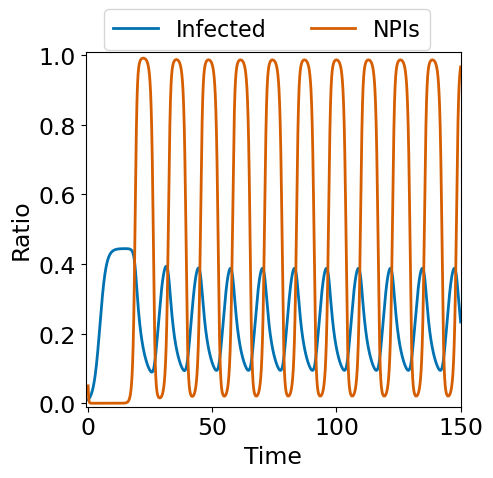

In [7]:
color_map=['#0072B2', '#D55E00', '#009E73', '#E69F00']
marker_shape = ['o','d','s','d']
plt.figure(figsize=(5,5))
plt.plot(t_eval, I_list, color=color_map[0],linewidth=2,label="Infected")
plt.plot(t_eval, p_list, color=color_map[1],linewidth=2,label="NPIs")

font1 = {'weight': 'normal','size':17}
font2 = {'weight': 'normal','size':17}
#plt.legend(fontsize=16)
plt.ylim((-0.01,1.01))
plt.xlim((-1,150))
plt.legend(ncol=2, loc="upper left", bbox_to_anchor=(0.05, 1.12), borderaxespad=0, fontsize=16)
#plt.xticks([0,0.02,0.04,0.06,0.08],['0','0.02','0.04','0.06','0.08'])
plt.subplots_adjust(left=0.19,bottom=0.17,right=0.94)
plt.tick_params(labelsize=17)
#plt.xlabel('Infection rate, $\\beta$',font1)
#plt.xlabel('cI',font1)
#plt.xlabel('alpha',font1)
#plt.xlabel('gamma',font1)
plt.xlabel('Time',font1)
plt.ylabel('Ratio',font1)

plt.savefig(_Figure_PATH_XX_ + 'ita-time-01' + '.png', dpi = 400)
plt.plot()